# Appendix: functions, tensor shapes, and conventions

This notebook is a compact reference for the helper functions used in `diffusion_intro.ipynb`. It documents their inputs, outputs, tensor shapes, and indexing conventions.

The main notebook explains the diffusion process, training objective, and sampling procedure. The reverse DDPM sampler is therefore not demonstrated here.

In [14]:
import torch
import matplotlib.pyplot as plt

from funs.SineWave_Dataset import SineWave_DataSet
from funs.scheduler import (
    noise_scheduler,
    add_noise_onestep,
    add_noise_onestep_cum_sampler,
    add_noise_from_zero,
)
from funs.time_embedding import get_sinusoidal_table
from funs.unet_1d import ConditionalUNet1D

torch.manual_seed(7)
plt.rcParams["figure.figsize"] = (5, 3)

## Conventions

The code uses the following symbols and tensor layouts:

| Symbol | Meaning |
|---|---|
| `B` | Batch size |
| `L` | Signal length |
| `T` | Number of entries in the diffusion schedule |
| `t` | Zero-based schedule index, with `0 <= t < T` |

Because Python uses zero-based indexing, `t = 0` applies the first noise transition. Therefore

$$
\bar{\alpha}_t = \prod_{i=0}^{t} \alpha_i,
$$

and the iterative implementation applies schedule entries `0, ..., t`. Equivalently, schedule index `t` represents `t + 1` noise transitions from the clean sample.

| Quantity | Shape |
|---|---|
| One frequency condition for the sine wave (data) | `[1]` |
| One clean signal | `[L]` |
| Batched signals | `[B, L]` |
| U-Net input | `[B, 1, L]` |
| Timesteps | `[B]` |
| Predicted noise | `[B, 1, L]` |

## Functions and objects

| Function or class | Purpose |
|---|---|
| `SineWave_DataSet` | Generate sine-wave training examples on demand |
| `noise_scheduler` | Construct the forward and reverse schedule coefficients |
| `add_noise_onestep` | Apply one Markov noise transition (add noise for one step) |
| `add_noise_onestep_cum_sampler` | Apply transitions repeatedly for demonstrations and empirical checks |
| `add_noise_from_zero` | Sample a noisy signal directly from a clean signal |
| `get_sinusoidal_table` | Construct fixed timestep embeddings |
| `ConditionalUNet1D` | Predict the noise contained in a noisy signal |

The reverse-process function `ddpm_sampler` is demonstrated in the main notebook.

## Procedural sine-wave dataset

`SineWave_DataSet` generates a new sample whenever `__getitem__` is called; it does not retrieve a fixed stored example. The dataset index is therefore ignored.

For each sample, the dataset draws a frequency uniformly from `[0, freq_max)` and evaluates the sine wave at `L` equally spaced coordinates between `0` and `2π`. It returns:

1. A frequency tensor with shape `[1]`.
2. A signal tensor with shape `[L]`.

frequency: 2.675
frequency shape: (1,)
signal shape: (200,)


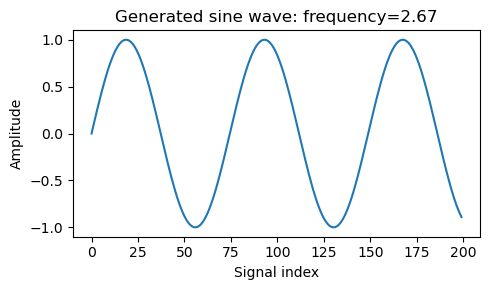

In [15]:
dataset = SineWave_DataSet(freq_max=5, n_dim=200)
frequency, x_clean = dataset[0]

print(f"frequency: {frequency.item():.3f}")
print(f"frequency shape: {tuple(frequency.shape)}")
print(f"signal shape: {tuple(x_clean.shape)}")

plt.plot(x_clean)
plt.xlabel("Signal index")
plt.ylabel("Amplitude")
plt.title(f"Generated sine wave: frequency={frequency.item():.2f}")
plt.tight_layout()
plt.show()

## Linear noise schedule

In general, the scheduler and its schedules determine how much noise to add for each time step during the corruption process. Due to the assumptions of how the samples are corrupted, instead of corrupting the samples one at a time (t-1 to t), we can go immediately from (0 to t). Because they help schedule how the samples are corrupted, they also play a role in the reverse process.

Their definitions are important, but not the priority to understand the method for the context of this tutorial. 

We only check their shapes here, which correspond to the number of time steps used in diffusion model.


In [18]:
T = 500
schedule = noise_scheduler(beta_min=1e-4, beta_max=0.02, T=T)

for name, values in schedule.items():
    print(
        f"{name:32s} "
        f"shape={tuple(values.shape)}, "
    )

Adopting a linear scheduler
betas                            shape=(500,), 
alphas                           shape=(500,), 
alpha_hats                       shape=(500,), 
alpha_hats_sqrt                  shape=(500,), 
one_minus_alpha_hats_sqrt        shape=(500,), 
posterior_variance               shape=(500,), 


## Forward-noise helpers

One Markov transition is

$$
x_{t+1} = \sqrt{\alpha_t}\,x_{t} + \sqrt{\beta_t}\,\epsilon_t,
\qquad \epsilon_t \sim \mathcal{N}(0, I).
$$

Repeated transitions can be replaced by the direct expression

$$
x_{t+1} = \sqrt{\bar{\alpha}_t}\,x_{\mathrm{clean}}
+ \sqrt{1-\bar{\alpha}_t}\,\epsilon.
$$

`add_noise_onestep_cum_sampler` implements the repeated construction and costs `O(t)` operations per sample. It is useful for visualization and empirical checks. `add_noise_from_zero` implements the direct `O(1)` construction used during training.

Here for the same sample, we generate the corrupted sample at timesteps (10, 100, 200, 400). For each time step, three samples are generated. With greater time step, the sample look more like random noise.


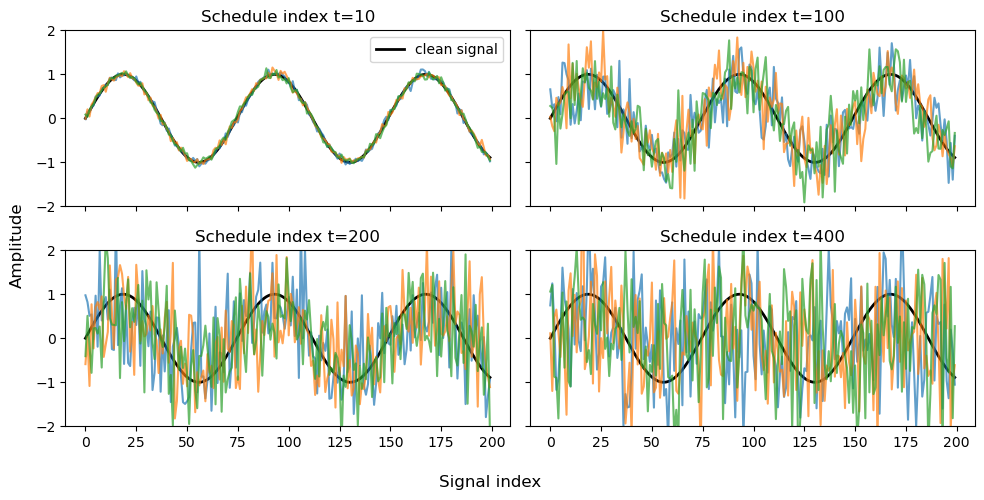

In [5]:
timesteps = [10, 100, 200, 400]
fig, axes = plt.subplots(2, 2, figsize=(10, 5), sharex=True, sharey=True)

for ax, t in zip(axes.flat, timesteps):
    noisy_samples = add_noise_onestep_cum_sampler(
        x_clean.unsqueeze(0),
        t=t,
        scheduler_dict=schedule,
        no_samples=3,
    )

    ax.plot(x_clean, color="black", linewidth=2, label="clean signal")
    for noisy_sample in noisy_samples:
        ax.plot(noisy_sample, alpha=0.7)

    ax.set_title(f"Schedule index t={t}")
    ax.set_ylim(-2, 2)

axes[0, 0].legend()
fig.supxlabel("Signal index")
fig.supylabel("Amplitude")
plt.tight_layout()
plt.show()

## Sinusoidal timestep embeddings

`get_sinusoidal_table(T, d_t)` creates one fixed embedding vector for each schedule index. Multiple sine and cosine frequencies give the network a structured, multi-scale representation of time. Here `d_t` is the time dimension, and has nothing to do with the derivative `d_t`. 

The embedding dimension must be even because half of the components use sine and half use cosine. The main notebook visualizes these components in detail.

In [17]:
time_table = get_sinusoidal_table(t_steps=T, t_dim=64)
example_t = 100
example_embedding = time_table[example_t]

assert time_table.shape == (T, 64)
assert example_embedding.shape == (64,)

print("embedding table shape:", tuple(time_table.shape))
print(f"embedding shape at t={example_t}:", tuple(example_embedding.shape))

embedding table shape: (500, 64)
embedding shape at t=100: (64,)


We visualize the timestep embedding below. Each dimension (each horizonal line in the upper figure) is a sin/cos curve. It can be viewed as year, month, day, hour, and etc that helps us better understand time than just a single number (e.g., the current time is 2026.7836 AD)

Text(0.5, 0, 'timestep')

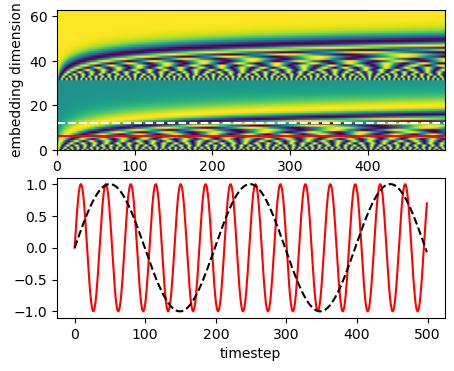

In [19]:
fig, ax = plt.subplots(2, 1, figsize=(5, 4))  # (width, height) in inches

im = ax[0].imshow(time_table.T,aspect="auto",origin="lower",cmap="viridis")
ax[0].axhline(y = [6], color = "red")
ax[0].axhline(y = [12], color = "white", linestyle = '--')


ax[0].set_xlabel("timestep")
ax[0].set_ylabel("embedding dimension")
ax[0].set_xlim(0, time_table.shape[0] - 1)     # x-axis is timestep index
ax[0].set_ylim(0, time_table.shape[1] - 1)     # y-axis is embedding dim index

ax[1].plot(time_table[:,6], color = 'red')
ax[1].plot(time_table[:,12],color = 'black', linestyle = '--')
ax[1].set_xlabel("timestep")


## Noise-prediction network

`ConditionalUNet1D` predicts the noise contained in a noisy signal. Its interface is:

- Noisy signal `x_t`: `[B, 1, L]`
- Schedule indices `t`: `[B]`
- Optional scalar condition: `[B, 1]`, or `None` for unconditional generation
- Predicted noise: `[B, 1, L]`

The model below is randomly initialized. This example checks only the interface and tensor shapes; its predictions are not yet meaningful.

In [24]:
B, L = 12, 200
model = ConditionalUNet1D(
    in_channels=1,
    base_channels=64,
    t_steps=T,
    t_dim=64,
    cond_dim=1,
    emb_dim=72,
)

x_t_dummy = torch.randn(B, 1, L)
t_dummy = torch.randint(0, T, (B,))

model.eval()
with torch.no_grad():
    unconditional_output = model(x_t_dummy, t_dummy, None)

assert unconditional_output.shape == x_t_dummy.shape
assert conditional_output.shape == x_t_dummy.shape

print("input shape:               ", tuple(x_t_dummy.shape))
print("time input shape           ", tuple(t_dummy.shape))
print("unconditional output shape:", tuple(unconditional_output.shape))

input shape:                (12, 1, 200)
time input shape            (12,)
unconditional output shape: (12, 1, 200)
